# Taller 7 - Análisis de Componentes Principales (PCA) en Fashion-MNIST
**Autores:** Sumin Han, Juan David Nieto

Dataset: Fashion MNIST

## 1. Importación de librerías

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

## 2. Carga y Descripción inicial del dataset
### Separar el conjunto en Train y Test (X: Los imagenes (28x28), Y: Las etiquetas (0-9)

In [ ]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

### Dimensiones de los datos de Entrenamiento

In [ ]:
print(f'Dimension de x_train: {x_train.shape}')
print(f'Dimension de y_train: {y_train.shape}')
print(f'Primero 5 etiquetas de y_train: {y_train[:5]}')

Dimension de x_train: (60000, 28, 28)
Dimension de y_train: (60000,)
Primero 5 etiquetas de y_train: [9 0 0 3 0]


### Visualización de algunas imágenes de ejemplo

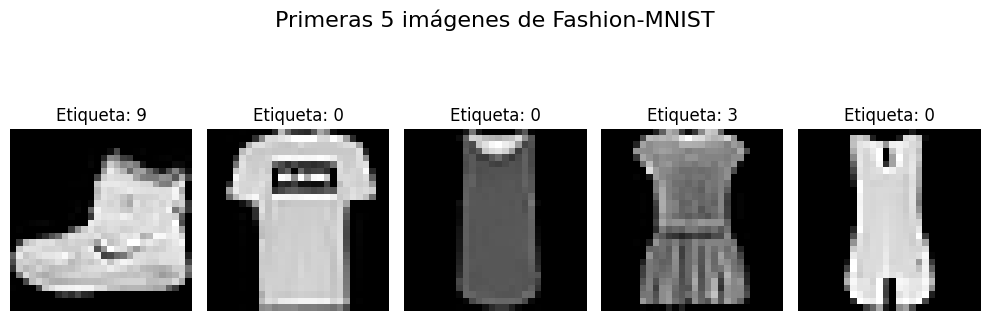

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Etiqueta: {y_train[i]}')
    plt.axis('off')
plt.suptitle('Primeras 5 imágenes de Fashion-MNIST', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
uniqueClass = np.unique(y_train)
num_classes = len(uniqueClass)
print(f'Numero de clases distintas: {num_classes}')
print(f'Etiquetas Numericas: {uniqueClass}')

Numero de clases distintas: 10
Etiquetas Numericas: [0 1 2 3 4 5 6 7 8 9]


Según Kaggle: https://www.kaggle.com/datasets/zalando-research/fashionmnist

"Labels

Each training and test example is assigned to one of the following labels:

*   **0:** T-shirt/top (Camiseta/blusa)
*   **1:** Trouser (Pantalón)
*   **2:** Pullover (Jersey)
*   **3:** Dress (Vestido)
*   **4:** Coat (Abrigo)
*   **5:** Sandal (Sandalias)
*   **6:** Shirt (Camisa)
*   **7:** Sneaker (Tenis)
*   **8:** Bag (Bolso)
*   **9:** Ankle boot (Botínes)"

### Preprocesamiento de datos: Aplanamiento (Flattening)

In [ ]:
#Flattening: Convertir cada Imagen 28x28 a un vector de 784 características
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print(f'Dimension de x_train_flat después de aplanar: {x_train_flat.shape}')
print(f'Dimension de x_test_flat después de aplanar: {x_test_flat.shape}')

Dimension de x_train_flat después de aplanar: (60000, 784)
Dimension de x_test_flat después de aplanar: (10000, 784)


###Normalización de los píxeles

In [ ]:
# Normalizar los valores de los píxeles de 0-255 a 0-1
x_train_norm = x_train_flat / 255
x_test_norm = x_test_flat / 255

print(f'Tamaño de x_train_norm: {x_train_norm.shape}')
print(f'Max de x_train_norm: {x_train_norm.max()}')
print(f'Min de of x_train_norm: {x_train_norm.min()}')

print(f'Tamaño de x_test_norm: {x_test_norm.shape}')
print(f'Min de x_test_norm: {x_test_norm.min()}')
print(f'Max de x_test_norm: {x_test_norm.max()}')

Tamaño de x_train_norm: (60000, 784)
Max de x_train_norm: 1.0
Min de of x_train_norm: 0.0
Tamaño de x_test_norm: (10000, 784)
Min de x_test_norm: 0.0
Max de x_test_norm: 1.0


###Por qué la normalización es importante para PCA?
En PCA, podemos enfrentarnos con datasets cuyo sus características tegan rangos diferentes. Por ejemplo, digamos que tenemos la característica A y B donde A puede variar entre 0-10 pero B puede tener un rango muchísimo más grande (0-1000 por ejemplo) y eso hace que al realizar PCA, el modelo va asumir de manera incorrecta que la característica B sea 1000 veces mas importante que A, haciendo que la caracterísitca A no influya tanto. Para evitar esto, el uso de normalización hace que todas las características estén en el mismo escala pero sacrificando la posible interpretación.

Otra razón que debemos tomar en cuenta en otros casos es que podemos enfretarnos con variables con diferentes unidades lo cuál es similar con la anterior razón donde algunas metricas puede dominar a otras.

In [ ]:
print(f'Valores faltantes en x_train: {np.isnan(x_train).sum()}')
print(f'Valores faltantes en x_test: {np.isnan(x_test).sum()}')
print(f'Valores faltantes en y_train: {np.isnan(y_train).sum()}')
print(f'Valores faltantes en y_test: {np.isnan(y_test).sum()}')

print(f'Valores faltantes en x_train_norm: {np.isnan(x_train_norm).sum()}')
print(f'Valores faltantes en x_test_norm: {np.isnan(x_test_norm).sum()}')

Valores faltantes en x_train: 0
Valores faltantes en x_test: 0
Valores faltantes en y_train: 0
Valores faltantes en y_test: 0
Valores faltantes en x_train_norm: 0
Valores faltantes en x_test_norm: 0


## 3. Aplicación de PCA
### Adjuste PCA sin especificar n_components

In [ ]:
# Inicializar PCA sin especificar n_components para analizar toda la varianza
pca = PCA()
pca.fit(x_train_norm)

print(f'PCA adjustado con {pca.n_components_} componentes.')

PCA adjustado con 784 componentes.


### Varianza Explicada por Componente Principal Individual

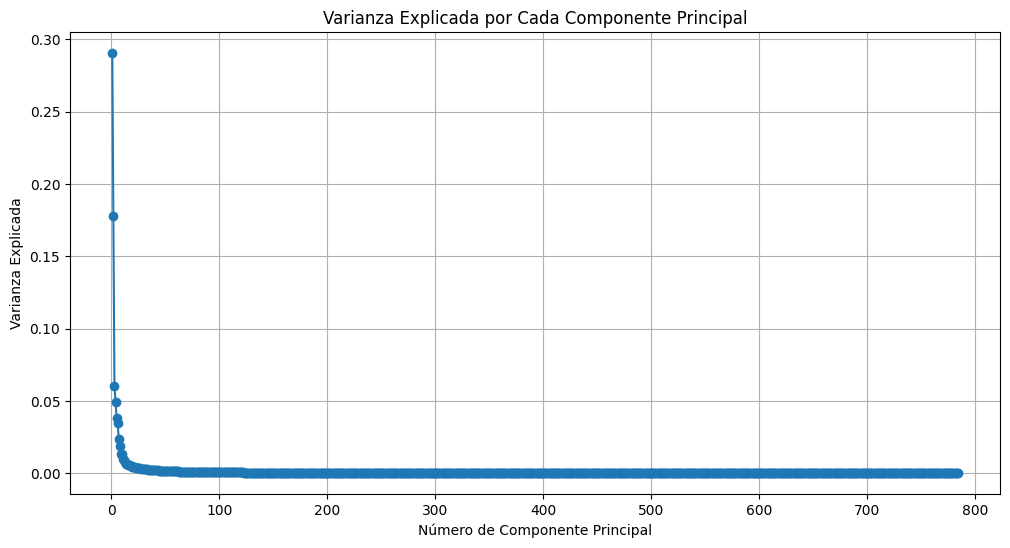

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='-')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Cada Componente Principal')
plt.grid(True)
plt.show()

### Varianza Explicada Acumulada

Para explicar el 85% de la varianza, se necesitan 43 componentes.
Para explicar el 90% de la varianza, se necesitan 84 componentes.
Para explicar el 95% de la varianza, se necesitan 187 componentes.


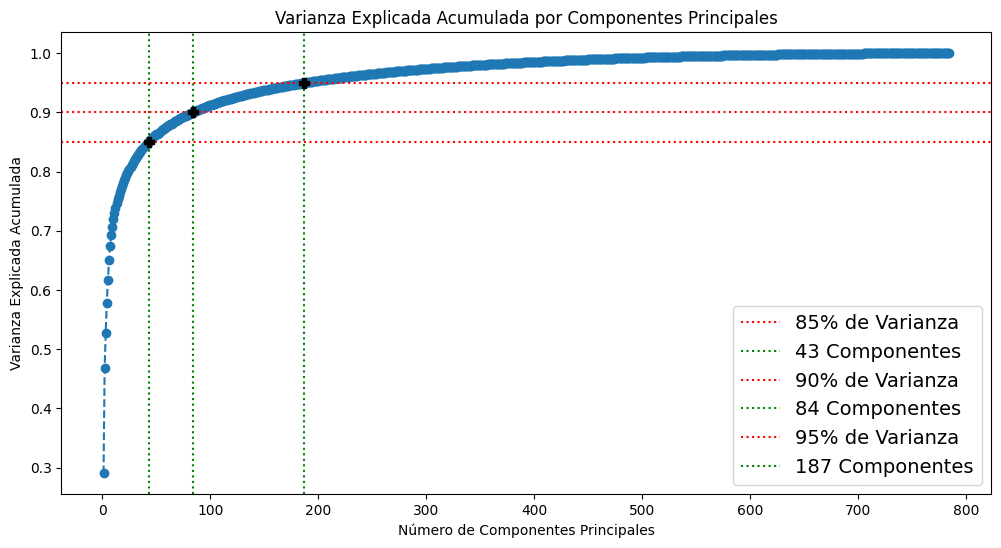

In [ ]:
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada Acumulada por Componentes Principales')

# Add lines and intersection points for 85%, 90%, and 95% explained variance
for threshold in [0.85, 0.90, 0.95]:
    num_components = np.argmax(cumulative_variance_ratio >= threshold) + 1
    plt.axhline(y=threshold, color='r', linestyle=':', label=f'{int(threshold*100)}% de Varianza')
    plt.axvline(x=num_components, color='g', linestyle=':', label=f'{num_components} Componentes')
    plt.plot(num_components, threshold, 'P', markersize=7, color='black')
    print(f'Para explicar el {int(threshold*100)}% de la varianza, se necesitan {num_components} componentes.')

plt.legend(fontsize=14)
plt.show()

Según la grafíca de la Varianza Explicada Acumulado por Componentes Principales, hallamos de que para poder explcar el 85% de la variaza del dataset original, necesitamos 43 componentes. Para explciar el 90%, se requiere 84 componentes, casi el doble de cantidad con solo incrementar 5% de la varianza lo cual es interesante. Y para explicar el 95%, necesitamos 187 componentes que es más el doble del anterior. Pareciera que el número de componentes principales se incrementatn de manera exponencial al incrementar la varianza explicada acumulada.

Esto ocurre debido a que si miramos la gráfica de Varianza Explciada por cada Componente Principal, los primeros componentes siempre son los que mayor varianza capturan y los demás la varianza capturada es muy pequeña y por ende cuando queremos explicar más la varianza, necesitamos más componentes para lograrlo ya que cada componenete subsucuente explica una porción más pequeña de la varianza faltante.

## 3. Visualizacióny Análisis de Componentes Principales


### Visualización de los Primeros Componentes Principales (Eigen-fashions)
Los componentes principales (eigenvectores) se encuentran en el atributo `components_` del objeto PCA ajustado. Cada componente tiene la misma dimensionalidad que los datos originales (784 píxeles). Los podemos visualizar como imágenes para entender qué patrones capturan.

In [ ]:
# Número de componentes principales a visualizar
n_comp = 10

# Obtener los primeros N componentes principales
# Cada fila de pca.components_ es un componente principal (un eigenvector)
primer_n_comp = pca.components_[:n_comp]

# Reshape los componentes a la forma original de la imagen (28x28)
eigen_fashions = primer_n_comp.reshape((n_comp, 28, 28))

print(f'Forma de los {n_comp} primeros eigen-fashions: {eigen_fashions.shape}')

Forma de los 10 primeros eigen-fashions: (10, 28, 28)


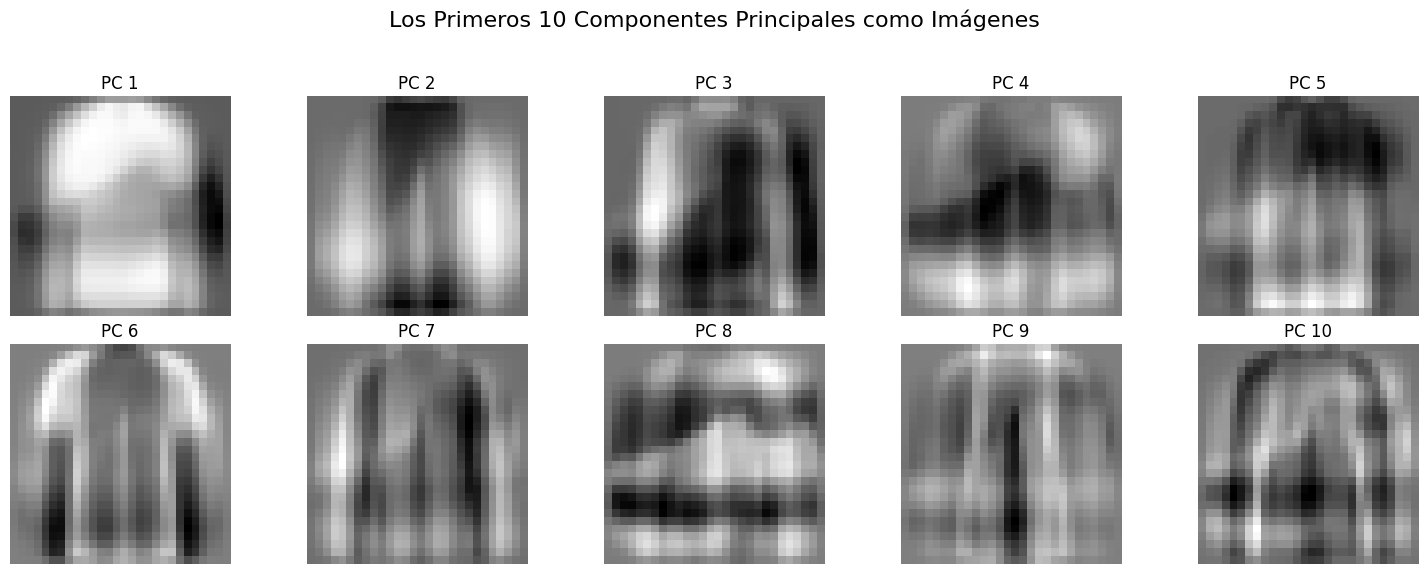

In [ ]:
plt.figure(figsize=(15, 6))
for i in range(n_comp):
    plt.subplot(2, 5, i + 1)
    plt.imshow(eigen_fashions[i], cmap='gray')
    plt.title(f'PC {i + 1}')
    plt.axis('off')
plt.suptitle(f'Los Primeros {n_comp} Componentes Principales como Imágenes', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Análisis de los Primeros Componentes Principales
Al visualizar los primeros componentes principales podemos observar lo siguiente:

*   **PC 1:** Como mencionado anteriormente, el primer componente es el que captura la mayor cantidad de varianza explicada y por eso se puede visualizar el brillo general o la intensidad de la imagen, o el contorno más básico del objeto. Puede verse como un patrón de luz y sombra general. También podemos ver 2 figuras, un torso y un zapato lo cuál hace que el modelo pueda diferenciar entre los objetos para el cuerpo superior y objetos pequeños como los zapatos. Como el torso tiene una intesidad más brillante que el zapato, puede significar que en este componente, los objetos de cuerpo superiro son como el centro. Teniendo esto en cuenta, pareciera que este componente esta intentando diferenciar entre objetos grandes (Camisetas, jerseys) con objetos pequeños (Zapatos, Sandlas), entonces podriamos llamar este componente como "Grande vs Pequeño".

*   **PC2:** Este componente también tiene una forma de un toroso pero pareciera que los brazos estén cubiertos con mangas lo cual puede significar que este componente consiste con ropa con magnas como los chaquetas o abrigos, enfocando en la parte de mangas ya que el antertior componente seguramente se centra en el area del pecho. También se ve una forma de pantalones oscuros lo cuál lo hace más notable. Como el anterior componente, esto puede significar que este componente esta separando la ropa con mangas largas con pantalones.

*   **PCs Subsiguientes:** Los componentes siguientes tienden a capturar características más detalladas y específicas como bordes, texturas, orientaciones y formas específicas de partes de la ropa (mangas, cuellos, dobladillos).

*   **Características Abstractas:** A medida que avanzamos, Las imágenes se vuelven más "complejas" y "granuladas" y así, los componentes pueden representar variaciones más abstractas que, combinadas, permiten reconstruir las distintas prendas. No siempre son directamente interpretables como objetos 'enteros', sino como 'bloques de construcción' de la variación en el dataset.

Estos componentes forman una base para la representación de las imágenes, donde cada imagen original puede ser vista como una combinación lineal de estos eigen-fashions.

### Proyección de Datos y Visualización 2D

Vamos a proyectar el conjunto de datos de entrenamiento en los dos primeros componentes principales para visualizar su separación por clases.

In [ ]:
# Ajustar PCA con n_components=2 y transformar los datos
pca_2d = PCA(n_components=2)
x_train_pca = pca_2d.fit_transform(x_train_norm)

print(f'Dimension de x_train_pca después de la transformación: {x_train_pca.shape}')

Dimension de x_train_pca después de la transformación: (60000, 2)


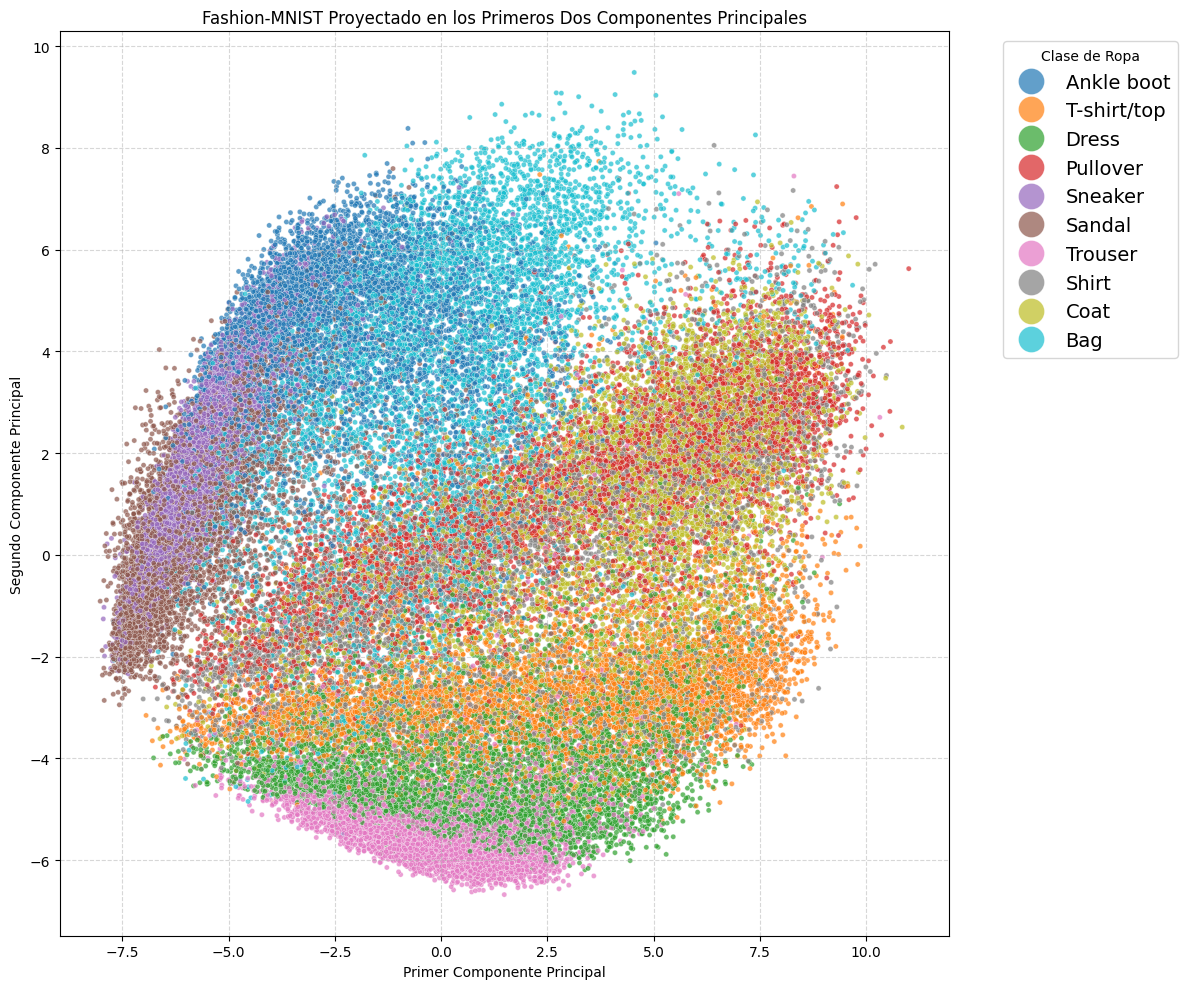

In [ ]:
import seaborn as sns

class_names = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

y_train_labels = [class_names[label] for label in y_train]

plt.figure(figsize=(12, 10))

sns.scatterplot(
    x=x_train_pca[:, 0], y=x_train_pca[:, 1],
    hue=y_train_labels,
    palette=sns.color_palette('tab10', n_colors=len(class_names)),
    alpha=0.7,
    s=14
)

plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.title('Fashion-MNIST Proyectado en los Primeros Dos Componentes Principales')
plt.legend(title='Clase de Ropa', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=5, fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Análisis de la Proyección 2D

*   **Separación de Clases:** Podemos ver que los dos primeros componentes princiapels separa los 10 diferentes clases de ropa de forma "moderada". Podemos distinguir diferentes grupos de colores, especialmente aquellos que esten cerca a uno de los ejes. Sin embargo, en el centro del plano ya se ve que está más complejo y hay varios colores como el rojo, amarillo y azúl.

*   **Clases Fáciles de Distinguir:** Las calses más faciles de distinguir son los que estén cerca a los ejes como la clase rosada (Trouser), verde (Dress), Azúl (Ankle Boot), magenta (Sneaker), marron (Sandals) y también el cyan (Bags) que tiene un valor alto.

*   **Clases Confundidas/Solapadas:** Los que tienden a superponerse son los que están en el medio lo cuál consiste con las clases de Shirts, Pullovers, y Coats ya que estos tienen una figura global simular (un torso) y tienen magas largas a diferencia del T-shirt (naranja) que está un poco más separada por debajo del nube central.

*   **Información Capturada:** El componente principal 1 captura "Tamaño/Intensidad": desplaza correctamente los zapatos hacia la izquierda y las prendas grandes hacia la derecha. Es un filtro categórico. Mientras el componente principal 2 captura "Relación de aspecto/Verticalidad": desplaza los pantalones hacia abajo y los bolsos/abrigos hacia arriba. Es un filtro estructural. En fín, los dos primeros componentes capturan la "esencia" de la imagen. Son suficientes para distinguir un zapato de una camisa, pero carecen de los detalles de alta frecuencia como el cuello, textura, botónes, etc.

## 4. Modelamiento usando PCA como características

###Importación de Librerías y Preparación de Datos PCA

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
import pandas as pd

###PCA Transformación para Diferentes Niveles de Varianza Explicada

In [ ]:
#Numero de Componentes para cada nivel de Varianza
num_comp_85 = np.argmax(cumulative_variance_ratio >= 0.85) + 1
num_comp_90 = np.argmax(cumulative_variance_ratio >= 0.90) + 1
num_comp_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1

print(f'# Componentes para 85% de varianza: {num_comp_85}')
print(f'# Componentes para 90% de varianza: {num_comp_90}')
print(f'# Componentes para 95% de varianza: {num_comp_95}')

pca_components = {
    '85%': num_comp_85,
    '90%': num_comp_90,
    '95%': num_comp_95
}

X_train_pca_datasets = {}
X_test_pca_datasets = {}

#Estandarizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train_norm)
X_test_scaled = scaler.transform(x_test_norm)

for variance_level, n_comps in pca_components.items():
    pca = PCA(n_components=n_comps)
    X_train_pca_datasets[variance_level] = pca.fit_transform(X_train_scaled)
    X_test_pca_datasets[variance_level] = pca.transform(X_test_scaled)
    print(f'Dimension de X_train_pca para {variance_level}: {X_train_pca_datasets[variance_level].shape}')
    print(f'Dimension de X_test_pca para {variance_level}: {X_test_pca_datasets[variance_level].shape}')

# Componentes para 85% de varianza: 43
# Componentes para 90% de varianza: 84
# Componentes para 95% de varianza: 187
Dimension de X_train_pca para 85%: (60000, 43)
Dimension de X_test_pca para 85%: (10000, 43)
Dimension de X_train_pca para 90%: (60000, 84)
Dimension de X_test_pca para 90%: (10000, 84)
Dimension de X_train_pca para 95%: (60000, 187)
Dimension de X_test_pca para 95%: (10000, 187)


### Función de Ayuda para Entrenamiento y Evaluación de Modelos

In [ ]:
results_df = pd.DataFrame(columns=['Model', 'Variance_Explained', 'Num_Components', 'Train_Accuracy', 'Test_Accuracy', 'Train_F1_Score', 'Test_F1_Score'])

def entreno_evaluacion(model, X_train, y_train, X_test, y_test, model_name, variance_level, num_components, is_dl=False):
    print(f"\n--- Entrenamiento {model_name} con Varianza de {variance_level} con ({num_components} componentes) ---")

    if is_dl:
        #Para deep learning, adjustar cond atos de validacion
        model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

        #Evaluar con datos de Entreno
        loss_train, acc_train = model.evaluate(X_train, y_train, verbose=0)
        y_pred_train = np.argmax(model.predict(X_train, verbose=0), axis=1)
        f1_train = f1_score(y_train, y_pred_train, average='weighted')

        #Evaluar con datos de Prueba
        loss_test, acc_test = model.evaluate(X_test, y_test, verbose=0)
        y_pred_test = np.argmax(model.predict(X_test, verbose=0), axis=1)
        f1_test = f1_score(y_test, y_pred_test, average='weighted')

        print(f'{model_name} - Accuracy Entreno: {acc_train:.4f}, Accuracy Entreno: {acc_test:.4f}')
        print(f'{model_name} - F1 Score Entreno: {f1_train:.4f}, F1 Score Prueba: {f1_test:.4f}')

    else:
        model.fit(X_train, y_train)

        # Predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        #Calcular métricas
        acc_train = accuracy_score(y_train, y_pred_train)
        f1_train = f1_score(y_train, y_pred_train, average='weighted')
        acc_test = accuracy_score(y_test, y_pred_test)
        f1_test = f1_score(y_test, y_pred_test, average='weighted')

        print(f'{model_name} - Train Accuracy: {acc_train:.4f}, Test Accuracy: {acc_test:.4f}')
        print(f'{model_name} - Train F1 Score: {f1_train:.4f}, Test F1 Score: {f1_test:.4f}')

    # Store results
    global results_df
    new_row = pd.DataFrame([{
        'Modelo': model_name,
        'Varianza Explicada': variance_level,
        'Num_Componentes': num_components,
        'Train_Accuracy': acc_train,
        'Test_Accuracy': acc_test,
        'Train_F1_Score': f1_train,
        'Test_F1_Score': f1_test
    }])
    results_df = pd.concat([results_df, new_row], ignore_index=True)


### 4.4 Entrenamiento y Evaluación de Modelos

#### RandomForestClassifier

In [ ]:
# RandomForestClassifier
for variance_level, n_comps in pca_components.items():
    model_rf = RandomForestClassifier(random_state=42)
    X_train_pca = X_train_pca_datasets[variance_level]
    X_test_pca = X_test_pca_datasets[variance_level]
    entreno_evaluacion(model_rf, X_train_pca, y_train, X_test_pca, y_test,
                             'RandomForestClassifier', variance_level, n_comps)


--- Entrenamiento RandomForestClassifier con Varianza de 85% con (43 componentes) ---
RandomForestClassifier - Train Accuracy: 1.0000, Test Accuracy: 0.8582
RandomForestClassifier - Train F1 Score: 1.0000, Test F1 Score: 0.8572

--- Entrenamiento RandomForestClassifier con Varianza de 90% con (84 componentes) ---


/tmp/ipykernel_4087/3541509301.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)


RandomForestClassifier - Train Accuracy: 1.0000, Test Accuracy: 0.8601
RandomForestClassifier - Train F1 Score: 1.0000, Test F1 Score: 0.8586

--- Entrenamiento RandomForestClassifier con Varianza de 95% con (187 componentes) ---
RandomForestClassifier - Train Accuracy: 1.0000, Test Accuracy: 0.8618
RandomForestClassifier - Train F1 Score: 1.0000, Test F1 Score: 0.8599


#### SVC

In [ ]:
# SVC
for variance_level, n_comps in pca_components.items():
    model_svc = SVC(random_state=42)
    X_train_pca = X_train_pca_datasets[variance_level]
    X_test_pca = X_test_pca_datasets[variance_level]
    entreno_evaluacion(model_svc, X_train_pca, y_train, X_test_pca, y_test,
                             'SVC', variance_level, n_comps)


--- Entrenamiento SVC con Varianza de 85% con (43 componentes) ---
SVC - Train Accuracy: 0.8871, Test Accuracy: 0.8643
SVC - Train F1 Score: 0.8866, Test F1 Score: 0.8637

--- Entrenamiento SVC con Varianza de 90% con (84 componentes) ---
SVC - Train Accuracy: 0.9015, Test Accuracy: 0.8752
SVC - Train F1 Score: 0.9011, Test F1 Score: 0.8747

--- Entrenamiento SVC con Varianza de 95% con (187 componentes) ---
SVC - Train Accuracy: 0.9133, Test Accuracy: 0.8834
SVC - Train F1 Score: 0.9129, Test F1 Score: 0.8830


#### Deep Learning Model

In [ ]:
# Deep Learning Model
num_classes = len(np.unique(y_train))

for variance_level, n_comps in pca_components.items():
    model_dl = Sequential([
        Dense(128, activation='relu', input_shape=(n_comps,)),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model_dl.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    X_train_pca = X_train_pca_datasets[variance_level]
    X_test_pca = X_test_pca_datasets[variance_level]
    entreno_evaluacion(model_dl, X_train_pca, y_train, X_test_pca, y_test,
                             'DeepLearning', variance_level, n_comps, is_dl=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Entrenamiento DeepLearning con Varianza de 85% con (43 componentes) ---
DeepLearning - Accuracy Entreno: 0.9064, Accuracy Entreno: 0.8670
DeepLearning - F1 Score Entreno: 0.9065, F1 Score Prueba: 0.8673

--- Entrenamiento DeepLearning con Varianza de 90% con (84 componentes) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


DeepLearning - Accuracy Entreno: 0.9284, Accuracy Entreno: 0.8829
DeepLearning - F1 Score Entreno: 0.9280, F1 Score Prueba: 0.8827

--- Entrenamiento DeepLearning con Varianza de 95% con (187 componentes) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


DeepLearning - Accuracy Entreno: 0.9549, Accuracy Entreno: 0.8834
DeepLearning - F1 Score Entreno: 0.9547, F1 Score Prueba: 0.8829


### 4.5 Resumen de Resultados

In [ ]:
print('\n--- Resumen de Todos los Modelos ---')
display(results_df.sort_values(by=['Test_Accuracy'], ascending=False))


--- Resumen de Todos los Modelos ---


,Model,Variance_Explained,Num_Components,Train_Accuracy,Test_Accuracy,Train_F1_Score,Test_F1_Score,Modelo,Varianza Explicada,Num_Componentes
8,NaN,NaN,NaN,0.954883,0.8834,0.954739,0.882912,DeepLearning,95%,187.0
5,NaN,NaN,NaN,0.913267,0.8834,0.912882,0.882976,SVC,95%,187.0
7,NaN,NaN,NaN,0.928433,0.8829,0.928014,0.882721,DeepLearning,90%,84.0
4,NaN,NaN,NaN,0.901517,0.8752,0.901054,0.874654,SVC,90%,84.0
6,NaN,NaN,NaN,0.906433,0.8670,0.906462,0.867270,DeepLearning,85%,43.0
3,NaN,NaN,NaN,0.887150,0.8643,0.886561,0.863718,SVC,85%,43.0
2,NaN,NaN,NaN,1.000000,0.8618,1.000000,0.859895,RandomForestClassifier,95%,187.0
1,NaN,NaN,NaN,0.999983,0.8601,0.999983,0.858648,RandomForestClassifier,90%,84.0
0,NaN,NaN,NaN,0.999967,0.8582,0.999967,0.857158,RandomForestClassifier,85%,43.0
